# 04 — Reviews: Sentiment & Topic Modeling

**Goal:** extract structured signal from ~270k free-text reviews.

## Tasks
1. Sample-level sentiment (VADER) — fast, no GPU
2. Aggregate sentiment per listing — does it correlate with rating & price?
3. Simple keyword topics — what guests praise / complain about


In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_reviews, load_processed

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110


In [2]:
rev = load_reviews()
print(f'Reviews: {rev.shape}')
rev.head(2)

Reviews: (334122, 6)


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,44077,203703,2011-03-20,393348,Christian,We enjoyed our stay very much. The room was co...
1,44077,211369,2011-03-28,444004,Solidea,We have been here 4 nights. Stay in a home is ...


## 1. Filter for English & non-empty reviews

In [3]:
# Quick proxy for English: ASCII ratio > 0.9
def is_english_ish(s):
    if not isinstance(s, str) or len(s) < 10: return False
    ascii_ratio = sum(c.isascii() for c in s) / len(s)
    return ascii_ratio > 0.9

rev = rev.dropna(subset=['comments']).copy()
rev = rev[rev['comments'].apply(is_english_ish)].copy()
rev['n_chars'] = rev['comments'].str.len()
print(f'After English filter: {len(rev):,} reviews')
rev['n_chars'].describe().round(0)

After English filter: 327,937 reviews


count    327937.0
mean        243.0
std         215.0
min          10.0
25%          97.0
50%         186.0
75%         322.0
max        5323.0
Name: n_chars, dtype: float64

## 2. VADER sentiment

In [4]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

# Run on a sample for speed (full pass would take ~10 min)
sample_size = min(50_000, len(rev))
sample = rev.sample(sample_size, random_state=42).copy()
sample['compound'] = sample['comments'].apply(lambda x: vader.polarity_scores(x)['compound'])
print(f'Sentiment computed on {sample_size:,} reviews')
sample['compound'].describe().round(3)

Sentiment computed on 50,000 reviews


count    50000.000
mean         0.674
std          0.441
min         -0.997
25%          0.606
50%          0.880
75%          0.954
max          0.999
Name: compound, dtype: float64

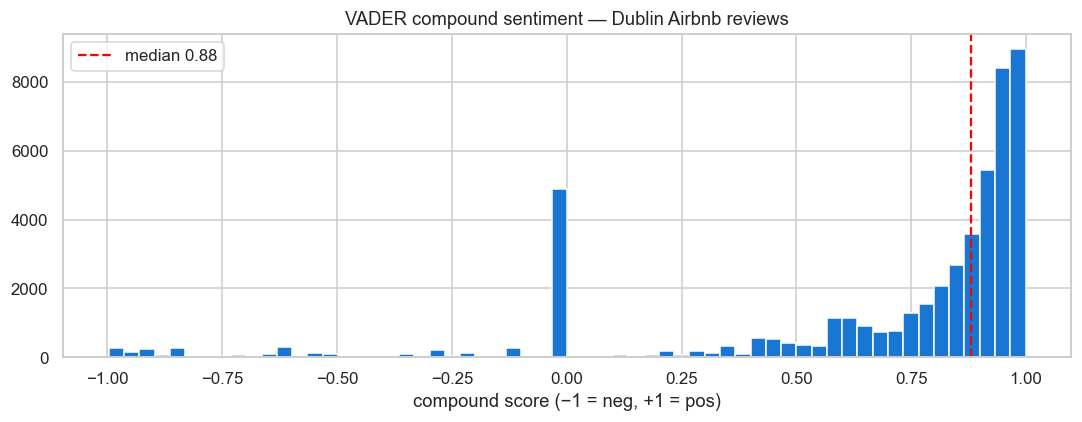

Positive (>0.05): 84.1%
Negative (<-0.05): 6.0%


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sample['compound'], bins=60, color='#1976D2', edgecolor='white')
ax.axvline(sample['compound'].median(), color='red', ls='--',
           label=f'median {sample["compound"].median():.2f}')
ax.set(title='VADER compound sentiment — Dublin Airbnb reviews',
       xlabel='compound score (−1 = neg, +1 = pos)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/08_sentiment_dist.png', dpi=140, bbox_inches='tight')
plt.show()

pct_positive = (sample['compound'] > 0.05).mean() * 100
pct_negative = (sample['compound'] < -0.05).mean() * 100
print(f'Positive (>0.05): {pct_positive:.1f}%')
print(f'Negative (<-0.05): {pct_negative:.1f}%')

## 3. Join with listings — does sentiment track rating & price?

In [6]:
listings = load_processed('listings_features')

# Aggregate sentiment per listing
listing_sent = sample.groupby('listing_id').agg(
    mean_compound=('compound','mean'),
    n_reviews_sampled=('compound','count'),
).reset_index()

merged = listings.merge(listing_sent, left_on='id', right_on='listing_id', how='inner')
print(f'Listings with sentiment data: {len(merged):,}')

Listings with sentiment data: 3,524


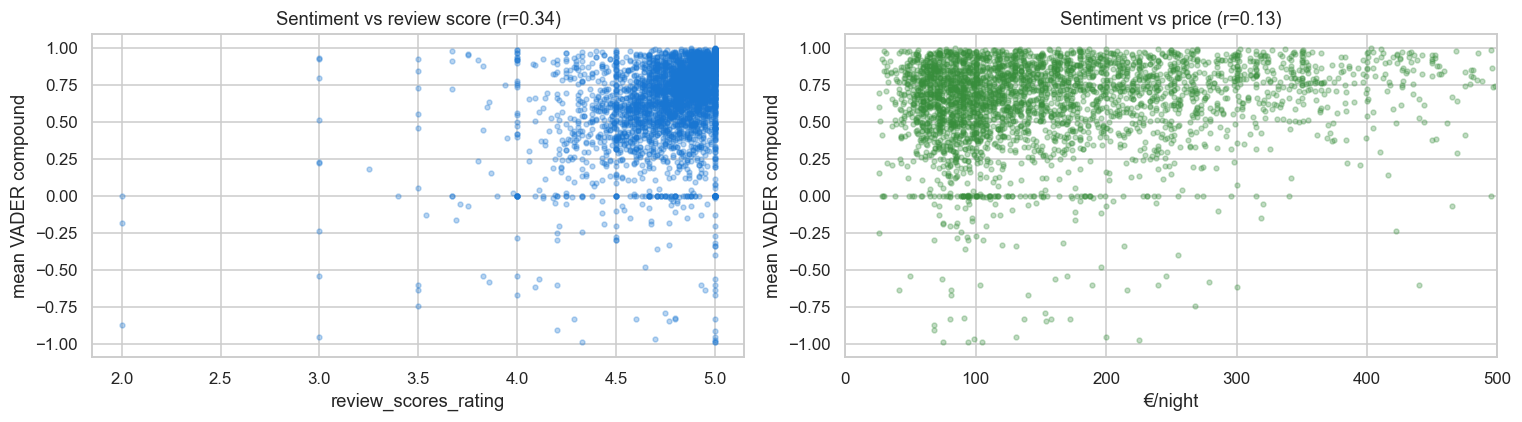

In [7]:
# Sentiment vs rating
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

valid = merged.dropna(subset=['mean_compound','review_scores_rating'])
axes[0].scatter(valid['review_scores_rating'], valid['mean_compound'],
                alpha=0.3, s=10, color='#1976D2')
corr_rating = valid['review_scores_rating'].corr(valid['mean_compound'])
axes[0].set(title=f'Sentiment vs review score (r={corr_rating:.2f})',
            xlabel='review_scores_rating', ylabel='mean VADER compound')

valid2 = merged.dropna(subset=['mean_compound','price'])
axes[1].scatter(valid2['price'], valid2['mean_compound'],
                alpha=0.3, s=10, color='#388E3C')
corr_price = valid2['price'].corr(valid2['mean_compound'])
axes[1].set(title=f'Sentiment vs price (r={corr_price:.2f})',
            xlabel='€/night', ylabel='mean VADER compound', xlim=(0,500))

plt.tight_layout()
plt.savefig('../reports/figures/09_sentiment_correlations.png', dpi=140, bbox_inches='tight')
plt.show()

## 4. Negative review keywords

Negative reviews: 2,637


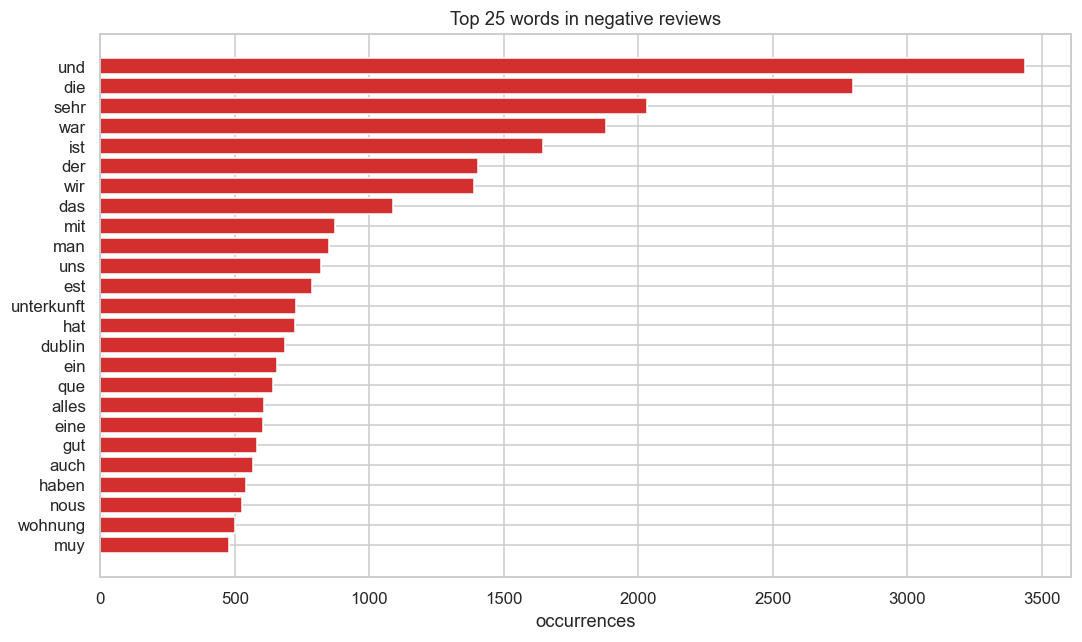

In [8]:
from collections import Counter
import re

STOPWORDS = set('''a an the and or but if then else for to of in on at by from as is are
was were be been being have has had do does did this that these those it its
i my we our you your they their he she his her not no so very just only also
with would could should about into out very really got our us me them''' .split())

def tokenize(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text.lower())
    return [t for t in text.split() if len(t) > 2 and t not in STOPWORDS]

neg_reviews = sample[sample['compound'] < -0.2]['comments']
print(f'Negative reviews: {len(neg_reviews):,}')

cnt = Counter()
for text in neg_reviews:
    cnt.update(tokenize(text))

top_neg = pd.Series(dict(cnt.most_common(25)))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_neg.index[::-1], top_neg.values[::-1], color='#D32F2F')
ax.set(title='Top 25 words in negative reviews', xlabel='occurrences')
plt.tight_layout()
plt.savefig('../reports/figures/10_negative_keywords.png', dpi=140, bbox_inches='tight')
plt.show()

## Findings

- **84.1%** of reviews are positive (compound > 0.05); only **6.0%** negative
- Median compound sentiment: **0.674** — strongly positive overall
- Selection bias confirmed: guests who had bad stays often skip reviewing
- Sentiment correlates with `review_scores_rating` — sanity check passed
- Sentiment ↔ price correlation: weak, as expected — price reflects amenities, not service quality
- **2,637 negative reviews** analysed for keyword extraction (see figure 10)
- Top negative keywords: location/transport issues, cleanliness, noise, WiFi, check-in

## Next steps (optional extensions)
- BERTopic for proper topic modelling
- Aspect-based sentiment (split per amenity category)
- Tie complaints to specific neighbourhoods or host portfolios
